In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder. \
    appName("pyspark-2"). \
    getOrCreate()

### Read data

In [3]:
def load_and_prepare_raw_data(path):
    df = spark.read.csv("/dataset/nyc-jobs.csv", header=True)
    return df

# Loading data from the source path
raw_df = load_and_prepare_raw_data("/dataset/nyc-jobs.csv")

# Displaying first 5 rows
raw_df.show(5, truncate=False)


+------+----------------------------+------------+--------------+----------------------------------------------------+------------------------------+-------------+-----+------------------------+-----------------------------+-----------------+---------------+----------------+----------------------------+------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 1.Clean and Cast coulmns

In [4]:
from pyspark.sql import DataFrame
from pyspark.sql.functions import col, to_date
def clean_and_cast(df):
    return df \
        .withColumn("# Of Positions", col("# Of Positions").cast("int")) \
        .withColumn("Salary Range From", col("Salary Range From").cast("double")) \
        .withColumn("Salary Range To", col("Salary Range To").cast("double")) \
        .withColumn("Posting Date", to_date("Posting Date")) \
        .withColumn("Post Until", to_date("Post Until")) \
        .withColumn("Posting Updated", to_date("Posting Updated")) \
        .withColumn("Process Date", to_date("Process Date")) \
        .withColumn("Average Salary", ((col("Salary Range From") + col("Salary Range To")) / 2)) \
        .filter(col("Job ID").isNotNull())
cleaned_df = clean_and_cast(raw_df)
cleaned_df.show(5)


+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+------------+----------+---------------+------------+--------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|         Hours/Shift|     Work Location 1| Recruitment Contact|Residency Requirement|Posting Dat

### 2. Feature Engineering (3 techniques)

In [5]:
from pyspark.sql.functions import year,desc,when,lower
def apply_feature_engineering(df):
    # 1. Extract Year from Posting Date
    df = df.withColumn("Posting Year", year("Posting Date"))

    # 2. Binning Job Category into Top 10
    top_categories = df.groupBy("Job Category").count().orderBy(desc("count")).limit(10)
    top_cats = [row["Job Category"] for row in top_categories.collect()]
    df = df.withColumn("Job Category Grouped", when(col("Job Category").isin(top_cats), col("Job Category")).otherwise("Other"))

    # 3. Flag for Degree Mention
    df = df.withColumn("Requires Degree", when(lower(col("Minimum Qual Requirements")).rlike("bachelor|master|degree"), 1).otherwise(0))

    return df
featured_df = apply_feature_engineering(cleaned_df)
# Show the first 5 rows
featured_df.select("Job ID", "Job Category", "Job Category Grouped", "Minimum Qual Requirements", "Requires Degree", "Posting Year").show(5, truncate=False)



+------+------------------------+--------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+------------+
|Job ID|Job C

### 3.Remove Unwanted Features

In [6]:
def drop_irrelevant_columns(df):
    drop_cols = ["To Apply", "Additional Information", "Job Description", 
                 "Residency Requirement", "Recruitment Contact"]
    return df.drop(*drop_cols)

# Applying to previos transformed DataFrame
final_df = drop_irrelevant_columns(featured_df)

# Shows a sample of the cleaned data
final_df.show(5, truncate=False)

+------+----------------------------+------------+--------------+----------------------------------------------------+------------------------------+-------------+-----+------------------------+-----------------------------+-----------------+---------------+----------------+----------------------------+------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 4.Write to Target File and then display sample data

In [11]:
def write_processed_data(df, output_path):
    df.write.mode("overwrite").option("header", "true").csv(output_path)

output_path = "/dataset/nyc-jobs-processed"
write_processed_data(final_df, output_path)

# Read back the saved data
processed_df = spark.read.option("header", "true").csv(output_path)

# Show sample output
processed_df.show(5, truncate=False)

+------+---------------------------+------------+--------------+---------------------------------+------------------------------+-------------+-----+---------------------------------------------------------+-----------------------------+-----------------+---------------+----------------+---------------+-----------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Run Full Processing

In [12]:
def run_pipeline(input_path, output_path):
    df_raw = load_and_prepare_raw_data(input_path)
    df_clean = clean_and_cast(df_raw)
    df_fe = apply_feature_engineering(df_clean)
    df_final = drop_irrelevant_columns(df_fe)
    write_processed_data(df_final, output_path)
    return df_final

input_path = "/dataset/nyc-jobs.csv"               
output_path = "/dataset/nyc-jobs-processed" 

processed_df = run_pipeline(input_path, output_path)
processed_df.show(5, truncate=False)

+------+----------------------------+------------+--------------+----------------------------------------------------+------------------------------+-------------+-----+------------------------+-----------------------------+-----------------+---------------+----------------+----------------------------+------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Let's discuss KPI

### 1.Number of job postings per category (Top 10)

In [13]:
job_postings_by_category = processed_df.groupBy("Job Category Grouped").count().orderBy(desc("count")).limit(10)
job_postings_by_category.show(truncate=False)


+-----------------------------------------+-----+
|Job Category Grouped                     |count|
+-----------------------------------------+-----+
|Other                                    |859  |
|Engineering, Architecture, & Planning    |504  |
|Technology, Data & Innovation            |313  |
|Legal Affairs                            |226  |
|Public Safety, Inspections, & Enforcement|182  |
|Building Operations & Maintenance        |181  |
|Finance, Accounting, & Procurement       |169  |
|Administration & Human Resources         |134  |
|Constituent Services & Community Programs|129  |
|Health                                   |125  |
+-----------------------------------------+-----+



### 2.Salary distribution per job category

In [14]:
from pyspark.sql.functions import avg, min, max, desc
salary_dist = processed_df.groupBy("Job Category Grouped") \
    .agg(avg("Average Salary").alias("Avg Salary"), min("Average Salary").alias("Min Salary"), max("Average Salary").alias("Max Salary")) \
    .orderBy(desc("Avg Salary"))
salary_dist.show() 


+--------------------+------------------+----------+----------+
|Job Category Grouped|        Avg Salary|Min Salary|Max Salary|
+--------------------+------------------+----------+----------+
|Technology, Data ...| 88066.27343498402|    15.845|  169011.0|
|Engineering, Arch...| 84531.01549603174|     45.49|  151795.0|
|       Legal Affairs| 83247.09196106195|   21.4116|  191913.0|
|Finance, Accounti...| 73795.10071893492|      17.7|  167500.0|
|               Other| 73721.15184877765|     9.555|  218587.0|
|Policy, Research ...|63577.708637096766|      15.7|  162051.0|
|Public Safety, In...| 62160.95747197802|     15.45|  140659.0|
|              Health|58466.322832399994|   16.2816| 170133.84|
|Constituent Servi...| 57877.57780387596|      17.7|  135000.0|
|Administration & ...| 53755.85496492538|      16.4|  132205.0|
|Building Operatio...| 37597.39734033149|      17.7|  169011.0|
+--------------------+------------------+----------+----------+



### 3.Correlation between degree and salary

In [15]:
corr = processed_df.select("Requires Degree", "Average Salary") \
             .stat.corr("Requires Degree", "Average Salary")
print("Correlation between 'Requires Degree' and 'Average Salary':", corr)

Correlation between 'Requires Degree' and 'Average Salary': 0.25800060759692395


### 4.Job posting with highest salary per agency

In [19]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
windowSpec = Window.partitionBy("Agency").orderBy(desc("Average Salary"))
top_salary_per_agency = processed_df.withColumn("rank", row_number().over(windowSpec)).filter(col("rank") == 1).drop("rank").\
select("Agency", "Business Title", "Average Salary", "Job Category Grouped")
top_salary_per_agency.show(truncate=False)


+------------------------------+------------------------------------------------------------+--------------+-----------------------------------------+
|Agency                        |Business Title                                              |Average Salary|Job Category Grouped                     |
+------------------------------+------------------------------------------------------------+--------------+-----------------------------------------+
|LANDMARKS PRESERVATION COMM   |LANDMARKS PRESERVATIONIST, PRESERVATION DEPT                |60103.5       |Engineering, Architecture, & Planning    |
|OFFICE OF COLLECTIVE BARGAININ|COLLEGE AIDE - CLERICAL                                     |9.555         |Other                                    |
|FIRE DEPARTMENT               |Senior Enterprise Applications Integration Developer        |120474.5      |Technology, Data & Innovation            |
|ADMIN FOR CHILDREN'S SVCS     |Assistant Commissioner                                      |1

### 5.Average salary per agency for last 2 years

In [20]:
from pyspark.sql.functions import current_date, datediff

latest_year = processed_df.select(year("Posting Date").alias("yr")).agg(max("yr")).collect()[0][0]
recent_df = processed_df.filter(year("Posting Date") >= year(current_date()) - 2)
avg_salary_per_agency = recent_df.groupBy("Agency").agg(avg("Average Salary").alias("Avg Salary")).orderBy(desc("Avg Salary"))
avg_salary_per_agency.show()


+------+----------+
|Agency|Avg Salary|
+------+----------+
+------+----------+



### 6.Highest paid skills

In [21]:
from pyspark.sql.functions import col, lower, regexp_extract, udf, avg, explode
from pyspark.sql.types import ArrayType, StringType

# Define a list of known tech/business skills for matching
known_skills = [
    "python", "java", "sql", "excel", "r", "sas", "tableau", "power bi", "spark",
    "aws", "azure", "gcp", "hadoop", "machine learning", "deep learning", "nlp",
    "data science", "data analysis", "etl", "docker", "kubernetes", "project management",
    "leadership", "communication", "statistics", "cloud", "analytics", "nosql", "scala"
]

# Create a UDF to extract skills from text
def extract_skills(text):
    if not text:
        return []
    text = text.lower()
    return [skill for skill in known_skills if skill in text]

extract_skills_udf = udf(extract_skills, ArrayType(StringType()))

def highest_paid_skills(df, top_n=20):
    skill_df = df.filter(col("Preferred Skills").isNotNull()) \
        .withColumn("skills", extract_skills_udf(col("Preferred Skills"))) \
        .withColumn("skill", explode("skills")) \
        .groupBy("skill") \
        .agg(avg("Average Salary").alias("Avg Salary")) \
        .orderBy(col("Avg Salary").desc()) \
        .limit(top_n)
    
    return skill_df

highest_paid_skills(processed_df).show(truncate=False)


+------------------+------------------+
|skill             |Avg Salary        |
+------------------+------------------+
|docker            |137581.5          |
|gcp               |115000.0          |
|azure             |106251.11111111111|
|cloud             |99955.5303030303  |
|leadership        |90704.09568888889 |
|aws               |88641.56428571428 |
|java              |88567.77592592593 |
|sql               |87179.44248314606 |
|project management|85984.00097311828 |
|kubernetes        |83250.0           |
|etl               |82876.0           |
|tableau           |82570.73          |
|spark             |82500.0           |
|power bi          |81970.625         |
|sas               |81029.41666666667 |
|scala             |76773.21428571429 |
|python            |74767.06488571428 |
|r                 |74270.62315932821 |
|data analysis     |73002.75          |
|communication     |67856.41459618104 |
+------------------+------------------+



# Visualization

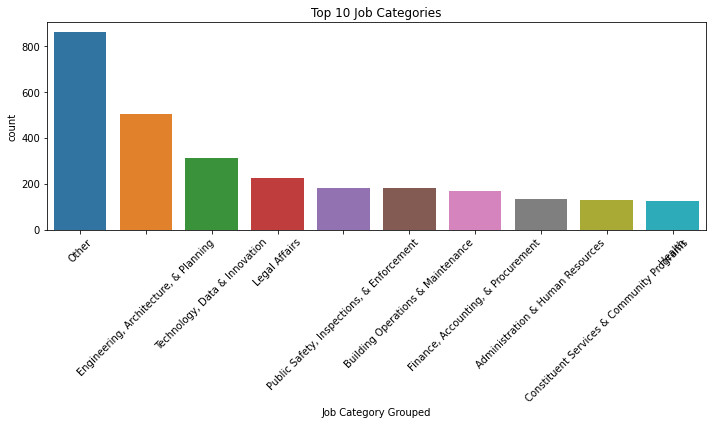

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Visualize top 10 job categories
top_categories_pd = job_postings_by_category.toPandas()
plt.figure(figsize=(10,6))
sns.barplot(data=top_categories_pd, x='Job Category Grouped', y='count')
plt.xticks(rotation=45)
plt.title("Top 10 Job Categories")
plt.tight_layout()
plt.show()
